In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import yaml
from PIL import Image, ImageDraw, ImageFont

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.build import build_finetune_loader, build_finetune_model
from src.finetune.checkpoint import load_trainable_state

CONFIG_PATH = ROOT / 'config/finetune_test.yaml'
LORA_PATH = None
BATCH_SIZE = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = yaml.safe_load(CONFIG_PATH.read_text())
model_config = dict(config['model'])
model_config['path'] = str(ROOT / model_config['path'])
model_config['device'] = device
model = build_finetune_model(model_config)
if LORA_PATH is not None:
    checkpoint = torch.load(LORA_PATH, map_location='cpu', weights_only=False)
    load_trainable_state(model, checkpoint['model'])
model.eval()

loader_config = dict(config['data']['valid'])
loader_config['folders'] = [dict(folder, path=str(ROOT / folder['path'])) for folder in loader_config['folders']]
loader_config['batch_size'] = BATCH_SIZE
loader_config['num_workers'] = 0
loader = build_finetune_loader(loader_config, train=False)
PROMPT_FONT = ImageFont.truetype('arial.ttf', 67)
PANEL_FONT = ImageFont.truetype('arial.ttf', 28)


In [2]:
def to_image(tensor):
    array = tensor.permute(1, 2, 0).numpy()
    return Image.fromarray(np.clip((array + 1) * 127.5, 0, 255).astype('uint8'))

def draw_prompt(image, prompt):
    image = image.copy()
    if prompt['mask'] is not None:
        mask = Image.fromarray((prompt['mask'] * 255).astype('uint8')).resize(image.size)
        red = Image.new('RGB', image.size, (255, 0, 0))
        image = Image.composite(Image.blend(image, red, 0.45), image, mask)
    draw = ImageDraw.Draw(image)
    if prompt['points'] is not None:
        for x, y in prompt['points']:
            draw.ellipse((x - 18, y - 18, x + 18, y + 18), fill='red')
    if prompt['box'] is not None:
        draw.rectangle(tuple(prompt['box']), outline='red', width=10)
    return image

def panel(image, text):
    image = image.resize((420, 420), Image.Resampling.NEAREST)
    ImageDraw.Draw(image).text((10, 10), text, font=PANEL_FONT, fill='white', stroke_width=2, stroke_fill='black')
    return image

def mask_panel(mask, text):
    image = Image.fromarray((mask * 255).astype('uint8')).convert('RGB')
    return panel(image, text)

def show_batch(batch, out):
    rows = []
    masks = (out['mask_logits'].sigmoid()[:, 0] >= 0.5).numpy()
    scores = out['iou_scores'][:, 0].numpy()
    classes = out['class_logits'][:, 0].sigmoid().numpy()
    for index in range(len(masks)):
        image = to_image(batch['image'][index])
        prompt = batch['prompt'][index]
        expected = batch['target'][index, 0].numpy() * float(batch['mask_valid'][index])
        label = batch['label_target'][index].int().tolist()
        name = 'background' if label[0] == 0 else ('frog' if label[1] == 1 else 'leaf')
        cond = int(batch['cond'][index])
        intersection = np.logical_and(masks[index], expected > 0.5).sum()
        union = np.logical_or(masks[index], expected > 0.5).sum()
        actual_iou = intersection / max(union, 1)
        rows.append((
            panel(draw_prompt(image, prompt), f"prompt: {prompt['type']}  cond={cond}"),
            mask_panel(masks[index], f'prediction\nIoU: {actual_iou:.3f} / {scores[index]:.3f}\nclass: {classes[index].round(3)}'),
            mask_panel(expected, f'target: {name}'),
        ))
    sheet = Image.new('RGB', (1260, 420 * len(rows)), 'white')
    for row_index, row in enumerate(rows):
        for column_index, item in enumerate(row):
            sheet.paste(item, (420 * column_index, 420 * row_index))
    return sheet


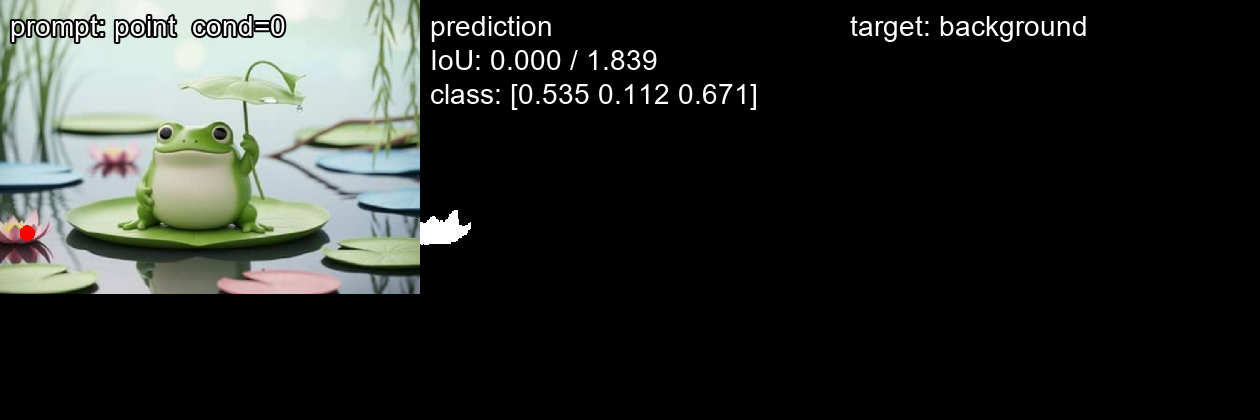

In [3]:
batch = next(loader)
model_batch = {key: value.to(device) if torch.is_tensor(value) else value for key, value in batch.items()}
with torch.inference_mode(), torch.autocast(device.type, enabled=device.type == 'cuda'):
    out = model(model_batch)
out = {key: value.float().cpu() for key, value in out.items()}
show_batch(batch, out)
